In [46]:
import numpy as np

def fun1():
    lst = [range(i,i+5)for i in [10,20,30,40,50]]
    print(lst)
    arr = np.array(lst)
    print(arr)
    
    arr1 = np.zeros_like(arr)
    print(arr1)
    
    print(arr[0:3,1:4])
    print(arr[2][3])
    print(arr[2,3])
    print(arr[2,3:5])
    print(arr[3:,1:])
    
    idxs = np.nonzero(arr>30) 
    print(idxs)

def fun2():
    """三维数组创建与切片操作"""
    # 创建一个 3×4×5 的三维数组，元素为 0~59
    arr3d = np.arange(60).reshape(3, 4, 5)
    print("三维数组 arr3d (shape=3×4×5):")
    print(arr3d)
    print()
    
    # 选取第 2 个二维切片（索引从0开始）
    print("arr3d[1, :, :] — 第2个二维矩阵:")
    print(arr3d[1, :, :])
    print()
    
    # 选取所有二维矩阵的第 2 行
    print("arr3d[:, 1, :] — 每个二维矩阵的第2行:")
    print(arr3d[:, 1, :])
    print()
    
    # 选取所有二维矩阵的第 3 列
    print("arr3d[:, :, 2] — 每个二维矩阵的第3列:")
    print(arr3d[:, :, 2])
    print()
    
    # 连续切片：第1~2个二维矩阵的第1~2行、第2~4列
    print("arr3d[0:2, 1:3, 2:5] — 子三维块:")
    print(arr3d[0:2, 1:3, 2:5])
    print()
    
    # 混合索引：第3个二维矩阵的第2行的第4~5列
    print("arr3d[2, 1, 3:5] — 第3个矩阵第2行的第4~5列:")
    print(arr3d[2, 1, 3:5])
    print()
    
    # 跳步切片：每2步取一个二维矩阵
    print("arr3d[::2] — 每隔一个取一个二维矩阵:")
    print(arr3d[::2])
    print()
    
    # 花式索引 + 切片：取第0和第2个二维矩阵的第1~3行
    print("arr3d[[0,2], 1:3, :] — 第1、3个矩阵的第2~3行:")
    print(arr3d[[0, 2], 1:3, :])
    print()
    
    # 布尔索引（三维）
    print("arr3d[arr3d > 40] — 所有大于40的元素:")
    print(arr3d[arr3d > 40])
    print()
    
    # 三维数组的转置
    print("arr3d.transpose(2, 0, 1) — 重排轴:")
    print(arr3d.transpose(2, 0, 1))
    
def fun3():
    arr2 = np.arange(10,20)
    print(arr2)
    idx_bool = np.array([True, False, True, False, True, False, True, False, True, False])
    print("布尔索引 idx_bool:")
    print(idx_bool)
    print("使用布尔索引筛选的元素:")
    print(arr2[idx_bool])
    arr3 = np.array([[1, 2 , 3], [3, 4, 5], [5, 6, 7]])
    print("三维数组 arr3:")
    print(arr3)
    
if __name__ == "__main__":
    #fun1()
    #fun2()
    fun3()

[10 11 12 13 14 15 16 17 18 19]
布尔索引 idx_bool:
[ True False  True False  True False  True False  True False]
使用布尔索引筛选的元素:
[10 12 14 16 18]
三维数组 arr3:
[[1 2 3]
 [3 4 5]
 [5 6 7]]


一、数组本质与属性
ndarray 是 NumPy 的核心数据结构，五个关键属性——shape（形状）、dtype（数据类型）、ndim（维度）、size（总元素数）、itemsize/nbytes（单元素和总字节数）。数据类型分整数（int8-64、uint8）、浮点（float16-64）和 object，浮点数底层按符号位+指数位+尾数位存储，会有精度误差。

二、创建方法
基础：np.array() 直接转列表，np.arange() 生成连续数组
定值：zeros/ones/full/eye/empty，还有 _like 系列快速复用已有形状
等差/随机：linspace 等间距，rand/randint/normal 三种随机
进阶参数：ndmin 指定维度，类型编码如 f4=float32、u1=uint8

三、形状修改
核心规则：总元素数不变。reshape() 比 直接改 shape 更常用，-1 让 NumPy 自动算某个维度。

四、索引与切片
一维跟 Python 列表一致
二维：arr[行,列]，逗号分隔维度；arr[:,1:4] 纵向切片；arr 按顺序取行
三维：想象成多张二维纸叠放，第一个维度是"第几张纸"，降维规则是某个维度用单个索引而非切片就会少一维
布尔索引用 True/False 过滤；np.nonzero() 找非零元素位置

五、广播机制
形状不同的数组运算时自动扩展对齐。触发条件：对应维度相同，或者其中一个为1。神经网络里不同层形状不一致时特别常用。

六、轴概念与聚合
二维：0轴=行方向，1轴=列方向。三维：0=切片，1=行，2=列。聚合哪根轴，哪根轴就消失——比如 shape=(4,3) 沿 axis=0 求和，结果就是 (3,)。

七、迭代顺序
np.nditer 的 order 参数：'C' 行优先（默认），'F' 列优先（Fortran 风格）。

八、常用函数
统计：mean/var/std/sum/max/min，都支持 axis
形状：reshape、.T 转置、swapaxes 交换轴
拼接增删：concatenate、append、delete
条件：np.where() 三元筛选
类型转换：astype()，转整数只截断不四舍五入
拷贝：np.array() 创建新内存，np.asarray() 只加引用省内存

In [43]:
import numpy as np

def fun1():
    arr1 = np.arange(1,10)
    arr2 = np.arange(1,10)
    print(arr1)
    print(arr2)
    print(arr1 + arr2)
    
def fun2():
    arr1 = np.arange(1,9).reshape(2,4)
    print(arr1)
    arr2 = np.array([[10],[20]])
    print(arr2.shape)
    print(arr1 + arr2)
    
    arr3 = np.array([[100,200,300,400]])
    print(arr1 + arr3)
    
    
    

if __name__ == "__main__":
    
    fun1()
    fun2()

[1 2 3 4 5 6 7 8 9]
[1 2 3 4 5 6 7 8 9]
[ 2  4  6  8 10 12 14 16 18]
[[1 2 3 4]
 [5 6 7 8]]
(2, 1)
[[11 12 13 14]
 [25 26 27 28]]
[[101 202 303 404]
 [105 206 307 408]]


In [45]:
import numpy as np

# 创建一个 2×4 的数组作为示例
a = np.arange(1, 9).reshape(2, 4)
print("原数组 a (shape=2×4):")
print(a)
print()

# ============ 1. order='C' — C order (行序优先) ============
# 按行遍历：先遍历第0行所有列，再遍历第1行所有列...
print("=" * 50)
print("np.nditer(a, order='C')  — 行序优先")
print("=" * 50)
print("遍历顺序: ")
for x in np.nditer(a, order='C'):
    print(x, end=' ')
print()

# 可以直观理解为：按内存中连续行优先的存储顺序依次取出元素
print("相当于按行展开: ", a.ravel(order='C'))
print()

# ============ 2. order='F' — Fortran order (列序优先) ============
# 按列遍历：先遍历第0列所有行，再遍历第1列所有行...
print("=" * 50)
print("np.nditer(a, order='F')  — 列序优先")
print("=" * 50)
print("遍历顺序: ")
for x in np.nditer(a, order='F'):
    print(x, end=' ')
print()

# 相当于按列展开
print("相当于按列展开: ", a.ravel(order='F'))
print()

# ============ 3. a.T + order='C' ============
# a.T 是转置（2×4 → 4×2）
# 对转置按行序遍历，相当于对原数组按列序遍历
print("=" * 50)
print("np.nditer(a.T, order='C')  — 先转置再行序优先")
print("=" * 50)
print("a.T (转置, shape=4×2):")
print(a.T)
print("遍历顺序: ")
for x in np.nditer(a.T, order='C'):
    print(x, end=' ')
print("\n")

# ============ 4. 对比总结用图表示 ============
print("=" * 50)
print("对比总结")
print("=" * 50)
print("数组 a:")
print(a)
print("\n遍历顺序对比:")
print("  order='C' (行优先):  ", end="")
for x in np.nditer(a, order='C'):   print(x, end=' ')
print("\n  order='F' (列优先):  ", end="")
for x in np.nditer(a, order='F'):   print(x, end=' ')
print("\n  a.T + order='C':     ", end="")
for x in np.nditer(a.T, order='C'): print(x, end=' ')
print()

print("\n✅ 说明:")
print("  order='C': 先遍历行 (按行展开)")
print("  order='F': 先遍历列 (按列展开)")
print("  a.T + order='C' 的结果等价于 order='F'")

原数组 a (shape=2×4):
[[1 2 3 4]
 [5 6 7 8]]

np.nditer(a, order='C')  — 行序优先
遍历顺序: 
1 2 3 4 5 6 7 8 
相当于按行展开:  [1 2 3 4 5 6 7 8]

np.nditer(a, order='F')  — 列序优先
遍历顺序: 
1 5 2 6 3 7 4 8 
相当于按列展开:  [1 5 2 6 3 7 4 8]

np.nditer(a.T, order='C')  — 先转置再行序优先
a.T (转置, shape=4×2):
[[1 5]
 [2 6]
 [3 7]
 [4 8]]
遍历顺序: 
1 5 2 6 3 7 4 8 

对比总结
数组 a:
[[1 2 3 4]
 [5 6 7 8]]

遍历顺序对比:
  order='C' (行优先):  1 2 3 4 5 6 7 8 
  order='F' (列优先):  1 5 2 6 3 7 4 8 
  a.T + order='C':     1 5 2 6 3 7 4 8 

✅ 说明:
  order='C': 先遍历行 (按行展开)
  order='F': 先遍历列 (按列展开)
  a.T + order='C' 的结果等价于 order='F'


In [44]:
import numpy as np

# ============================================================
# 实用案例：np.concatenate / np.append / np.delete
# ============================================================

print("=" * 60)
print("案例1: np.concatenate — 合并多个样本或特征")
print("=" * 60)

# 场景：3个学生的各科成绩，合并成一个班级成绩表
stu1 = np.array([[85, 90, 78]])   # 学生1 [数学, 英语, 物理]
stu2 = np.array([[92, 88, 95]])   # 学生2
stu3 = np.array([[70, 85, 80]])   # 学生3
class_score = np.concatenate([stu1, stu2, stu3], axis=0)
print("班级成绩表 (每行一个学生):")
print(class_score)
print()

# 场景：给成绩表增加「体育」一列
sport = np.array([[75], [80], [90]])  # 每个学生的体育成绩
full_score = np.concatenate([class_score, sport], axis=1)
print("增加体育列后的成绩表:")
print(full_score)
print()

# ============================================================

print("=" * 60)
print("案例2: np.append — 动态收集数据")
print("=" * 60)

# 场景：实时记录一天的体温数据（模拟）
temps = np.array([])  # 初始空数组
morning  = np.array([36.5, 36.7, 36.6])
noon     = np.array([37.0, 37.1, 36.9])
evening  = np.array([36.8, 36.6, 36.7])

temps = np.append(temps, morning)
temps = np.append(temps, noon)
temps = np.append(temps, evening)
print("全天体温记录:", temps)
print()

# 场景：给特征矩阵添加偏置项（全1列）
X = np.array([[2, 3], [4, 5], [6, 7]])   # 3个样本，2个特征
bias = np.ones((3, 1))                     # 全1列
X_with_bias = np.append(X, bias, axis=1)   # 或 np.concatenate([X, bias], axis=1)
print("原特征矩阵:")
print(X)
print("添加偏置列后 (用于线性回归):")
print(X_with_bias)
print()

# ============================================================

print("=" * 60)
print("案例3: np.delete — 数据清洗与特征选择")
print("=" * 60)

# 场景1：删除包含缺失值（-1 表示缺失）的样本行
data = np.array([
    [85, -1, 78],
    [92, 88, 95],
    [70, 85, -1],
    [88, 90, 92]
])
print("原始数据（-1 表示缺失）:")
print(data)
# 找到有缺失的行
bad_rows = np.any(data == -1, axis=1)
print("有缺失的行索引:", np.where(bad_rows)[0])
clean = np.delete(data, np.where(bad_rows)[0], axis=0)
print("清洗后的数据:")
print(clean)
print()

# 场景2：删除无关的特征列（如删除第1列「编号」）
data2 = np.array([
    [1, 85, 90, 78],   # [编号, 数学, 英语, 物理]
    [2, 92, 88, 95],
    [3, 70, 85, 80]
])
print("原始数据（含编号列）:")
print(data2)
data2_no_id = np.delete(data2, 0, axis=1)  # 删除第0列
print("删除编号列后:")
print(data2_no_id)

print("\n✅ 三个实用案例演示完毕！")

案例1: np.concatenate — 合并多个样本或特征
班级成绩表 (每行一个学生):
[[85 90 78]
 [92 88 95]
 [70 85 80]]

增加体育列后的成绩表:
[[85 90 78 75]
 [92 88 95 80]
 [70 85 80 90]]

案例2: np.append — 动态收集数据
全天体温记录: [36.5 36.7 36.6 37.  37.1 36.9 36.8 36.6 36.7]

原特征矩阵:
[[2 3]
 [4 5]
 [6 7]]
添加偏置列后 (用于线性回归):
[[2. 3. 1.]
 [4. 5. 1.]
 [6. 7. 1.]]

案例3: np.delete — 数据清洗与特征选择
原始数据（-1 表示缺失）:
[[85 -1 78]
 [92 88 95]
 [70 85 -1]
 [88 90 92]]
有缺失的行索引: [0 2]
清洗后的数据:
[[92 88 95]
 [88 90 92]]

原始数据（含编号列）:
[[ 1 85 90 78]
 [ 2 92 88 95]
 [ 3 70 85 80]]
删除编号列后:
[[85 90 78]
 [92 88 95]
 [70 85 80]]

✅ 三个实用案例演示完毕！


In [54]:
import copy

# 自定义 User 类
class User:
    def __init__(self, name, scores):
        self.name = name      # 姓名（不可变对象）
        self.scores = scores  # 成绩列表（可变对象！）

    def __repr__(self):
        return f"User({self.name}, {self.scores})"


# 创建几个 User 对象，添加到 UserList
user1 = User("Alice", [85, 90, 78])
user2 = User("Bob",   [92, 88, 95])
user3 = User("Cathy", [70, 85, 80])

UserList = [user1, user2, user3]

print("=" * 60)
print("原始 UserList:")
print("=" * 60)
for u in UserList:
    print(f"  {u}")

print("\n" + "=" * 60)
print("演示 copy() 与 deepcopy() 的区别")
print("=" * 60)

# -------------------- 浅拷贝 --------------------
shallow = copy.copy(UserList)

# -------------------- 深拷贝 --------------------
deep = copy.deepcopy(UserList)

# 修改原始列表中第一个用户的 scores（可变对象）
UserList[0].scores[0] = 999  # 把 Alice 的第一门成绩改成 999

print("\n【修改原始 UserList[0].scores[0] = 999 之后】")
print("此时 Alice 的 scores 发生了改变。\n")

print(f"原始 UserList:   {UserList}")
print(f"浅拷贝 shallow:  {shallow}")
print(f"深拷贝 deep:     {deep}")

print("\n" + "-" * 60)
print("结论分析:")
print("-" * 60)
print("  shallow (copy.copy):   浅拷贝只复制外层列表，内部 User 对象是共享引用")
print("                          所以原始对象修改 scores 后，shallow 也跟着变了 ❌")
print()
print("  deep   (copy.deepcopy):深拷贝递归复制所有嵌套对象，完全独立")
print("                          原始对象修改后，deep 不受影响 ✅")


原始 UserList:
  User(Alice, [85, 90, 78])
  User(Bob, [92, 88, 95])
  User(Cathy, [70, 85, 80])

演示 copy() 与 deepcopy() 的区别

【修改原始 UserList[0].scores[0] = 999 之后】
此时 Alice 的 scores 发生了改变。

原始 UserList:   [User(Alice, [999, 90, 78]), User(Bob, [92, 88, 95]), User(Cathy, [70, 85, 80])]
浅拷贝 shallow:  [User(Alice, [999, 90, 78]), User(Bob, [92, 88, 95]), User(Cathy, [70, 85, 80])]
深拷贝 deep:     [User(Alice, [85, 90, 78]), User(Bob, [92, 88, 95]), User(Cathy, [70, 85, 80])]

------------------------------------------------------------
结论分析:
------------------------------------------------------------
  shallow (copy.copy):   浅拷贝只复制外层列表，内部 User 对象是共享引用
                          所以原始对象修改 scores 后，shallow 也跟着变了 ❌

  deep   (copy.deepcopy):深拷贝递归复制所有嵌套对象，完全独立
                          原始对象修改后，deep 不受影响 ✅


In [55]:
import numpy as np

arr_3d = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

print("原始三维数组 arr_3d:")
print(arr_3d)
print("shape:", arr_3d.shape)  # (2, 2, 2)
print()

# 方法1: ravel() — 返回视图（不复制数据，修改会影响原数组）
print("ravel() 展平:", arr_3d.ravel())

# 方法2: flatten() — 返回副本（独立内存，修改不影响原数组）
print("flatten() 展平:", arr_3d.flatten())

# 方法3: reshape(-1) — 自动推断维度
print("reshape(-1) 展平:", arr_3d.reshape(-1))

# 验证形状
print("\n展平后 shape:", arr_3d.reshape(-1).shape)  # (8,)


原始三维数组 arr_3d:
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
shape: (2, 2, 2)

ravel() 展平: [1 2 3 4 5 6 7 8]
flatten() 展平: [1 2 3 4 5 6 7 8]
reshape(-1) 展平: [1 2 3 4 5 6 7 8]

展平后 shape: (8,)


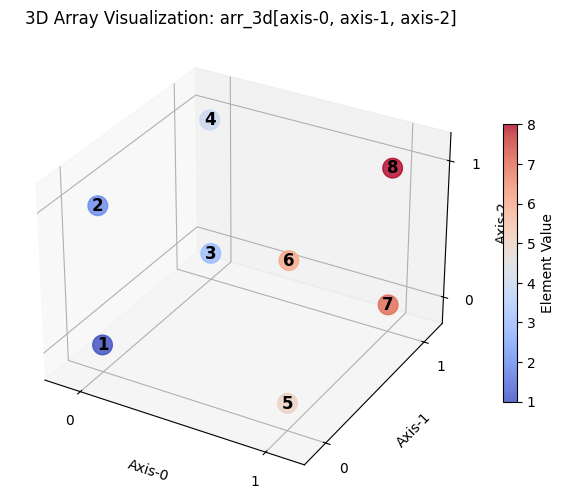

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# 获取每个元素的三维坐标 (i, j, k) 和对应的值
arr_3d = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

coords = []  # 坐标
values = []  # 元素值
for i in range(2):
    for j in range(2):
        for k in range(2):
            coords.append([i, j, k])
            values.append(arr_3d[i, j, k])

coords = np.array(coords)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 散点图，颜色表示元素值大小
sc = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                c=values, cmap='coolwarm', s=200, alpha=0.8)

# 标注每个点的值
for (i, j, k), v in zip(coords, values):
    ax.text(i, j, k, str(v), ha='center', va='center', fontsize=12, fontweight='bold')

# 设置坐标轴（英文）
ax.set_xlabel('Axis-0')
ax.set_ylabel('Axis-1')
ax.set_zlabel('Axis-2')

# 设置刻度
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_zticks([0, 1])
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_zlim(-0.2, 1.2)

# 添加颜色条
cbar = fig.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label('Element Value')

plt.title('3D Array Visualization: arr_3d[axis-0, axis-1, axis-2]')
plt.show()


In [5]:
import numpy as np

# 方法1: 直接创建 — 5×5 全1矩阵，再把内部 3×3 置为 0
arr = np.ones((5, 5), dtype=float)
arr[1:4, 1:4] = 0
print("方法1 (直接创建):")
print(arr)

# 方法2: 先创建全0，再设置边框为1
arr = np.zeros((5, 5), dtype=float)
arr[0, :] = arr[-1, :] = arr[:, 0] = arr[:, -1] = 1
print("方法2 (先创建全0，再设置边框为1):")
print(arr)

# 方法3: np.full + 切片赋值
arr3 = np.full((5, 5), 0, dtype=float)
arr3[0, :] = arr3[-1, :] = arr3[:, 0] = arr3[:, -1] = 1
print("方法3 (np.full + 切片):")
print(arr3)
print()

# 方法4: np.pad — 先创建 3×3 全0，再用 1 填充边框
arr4 = np.pad(np.zeros((3, 3), dtype=float), pad_width=1, mode='constant', constant_values=1)
print("方法4 (np.pad 填充):")
print(arr4)
print()

# 方法5: np.where + np.indices — 用坐标条件生成
i, j = np.indices((5, 5))
arr5 = np.where((i == 0) | (i == 4) | (j == 0) | (j == 4), 1.0, 0.0)
print("方法5 (np.indices + np.where):")
print(arr5)
print()

# 方法6: 布尔掩码索引
arr6 = np.zeros((5, 5), dtype=float)
mask = np.zeros((5, 5), dtype=bool)
mask[0, :] = mask[-1, :] = mask[:, 0] = mask[:, -1] = True
arr6[mask] = 1.0
print("方法6 (布尔掩码):")
print(arr6)

方法1 (直接创建):
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
方法2 (先创建全0，再设置边框为1):
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
方法3 (np.full + 切片):
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

方法4 (np.pad 填充):
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

方法5 (np.indices + np.where):
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

方法6 (布尔掩码):
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [6]:
import numpy as np

a = np.array([[1, 4, 2, 5],
              [5, 6, 7, 8],
              [9, 10, 12, 13]])
print("a (shape=3×4):")
print(a)
print()

c = np.array([[8, 7, 255, 6],
              [5, 255, 255, 255],
              [3, 5, 255, 255]])
print("c (255 表示异常/缺失):")
print(c)
print()

# 目标：c 中为 255 的位置保留 255，否则取 a 中对应位置的值
result = np.where(c == 255, c, a)
print("结果 (np.where 实现):")
print(result)


a (shape=3×4):
[[ 1  4  2  5]
 [ 5  6  7  8]
 [ 9 10 12 13]]

c (255 表示异常/缺失):
[[  8   7 255   6]
 [  5 255 255 255]
 [  3   5 255 255]]

结果 (np.where 实现):
[[  1   4 255   5]
 [  5 255 255 255]
 [  9  10 255 255]]


In [ ]:
import numpy as np

def fun1():
    print(np.hstack((np.array([1, 2, 3]), np.array([4, 5, 6])))) # 水平堆叠（按列连接）
    
    print(np.vstack((np.array([1, 2, 3]), np.array([4, 5, 6])))) # 垂直堆叠（按行连接）
    
    print(np.convolve(np.array([1, 2, 3]), np.array([0.2, 0.5, 0.3]))) # 一维卷积
    
    print(np.correlate(np.array([1, 2, 3]), np.array([0.2, 0.5, 0.3]))) # 一维相关
    
    print(np.squeeze(np.array([[[1], [2], [3]]]))) # 去掉单维度
    
def fun2():
    arr = np.arange(1, 10).reshape(1 ,3, 3)
    print(arr.shape) # (1, 3, 3)
    print(np.squeeze(arr).shape) # (3, 3)
    print(np.round(1.5555, 2))# 四舍五入保留2位小数
    print(np.ceil([1.5]))# 向上取整
    print(np.floor([1.5]))# 向下取整
    print(np.identity(5, dtype=np.int_))#
    print(np.min([1, 2, 3]))
    print(np.max([[1, 2, 3], [4, 5, 6]], axis=0))
    print(np.mean([1, 2, 3]))
    print(np.median(np.array([1, 1, 2.2, 3])))
    print(np.average([1, 4, 7], weights=[1, 2, 3]))
    print(np.squeeze([[1], [2], [3]]))
    
def fun3():
    arr2 = np.array([2,3])
    print(np.linalg.norm(arr2,ord=2)) # 计算向量的范数（长度）
    print(np.linalg.norm(arr2,ord=1)) # 计算向量的1-范数
    print(np.linalg.inv([[1, 2], [3, 4]])) # 计算矩阵的逆
    
    
if __name__ == "__main__":
    #fun1()
    #fun2()
    fun3()

3.605551275463989
[[-2.   1. ]
 [ 1.5 -0.5]]


In [22]:
import numpy as np

# 求距离
# 目标向量
target_vector = np.array([1, 2])
# 示例向量列表
names = ['sy', 'qq', 'lm', 'mgt']
vector_sy = np.array([4, 6])
vector_qq = np.array([1, 2])
vector_lm = np.array([10, 11])
vector_mgt = np.array([1, 3])

vectors = [vector_sy, vector_qq, vector_lm, vector_mgt]

# ---- 1. 计算距离 ----
results = []
for name, vec in zip(names, vectors):
    euclidean = np.sqrt(np.sum((vec - target_vector) ** 2))
    manhattan = np.sum(np.abs(vec - target_vector))
    results.append((name, vec, euclidean, manhattan))

print("原始顺序（未排序）:")
print(f"{'名称':<6} {'向量':<12} {'欧氏距离':<10} {'曼哈顿距离':<10}")
print("-" * 40)
for name, vec, eu, ma in results:
    print(f"{name:<6} {str(vec):<12} {eu:<10.4f} {ma:<10.4f}")

print()

# ---- 2. 按欧氏距离排序（近→远） ----
sorted_by_euclidean = sorted(results, key=lambda x: x[2])
print("按欧氏距离排序（近 → 远）:")
print(f"{'名称':<6} {'向量':<12} {'欧氏距离':<10} {'曼哈顿距离':<10}")
print("-" * 40)
for name, vec, eu, ma in sorted_by_euclidean:
    print(f"{name:<6} {str(vec):<12} {eu:<10.4f} {ma:<10.4f}")

print()

# ---- 3. 按曼哈顿距离排序（近→远） ----
sorted_by_manhattan = sorted(results, key=lambda x: x[3])
print("按曼哈顿距离排序（近 → 远）:")
print(f"{'名称':<6} {'向量':<12} {'欧氏距离':<10} {'曼哈顿距离':<10}")
print("-" * 40)
for name, vec, eu, ma in sorted_by_manhattan:
    print(f"{name:<6} {str(vec):<12} {eu:<10.4f} {ma:<10.4f}")


原始顺序（未排序）:
名称     向量           欧氏距离       曼哈顿距离     
----------------------------------------
sy     [4 6]        5.0000     7.0000    
qq     [1 2]        0.0000     0.0000    
lm     [10 11]      12.7279    18.0000   
mgt    [1 3]        1.0000     1.0000    

按欧氏距离排序（近 → 远）:
名称     向量           欧氏距离       曼哈顿距离     
----------------------------------------
qq     [1 2]        0.0000     0.0000    
mgt    [1 3]        1.0000     1.0000    
sy     [4 6]        5.0000     7.0000    
lm     [10 11]      12.7279    18.0000   

按曼哈顿距离排序（近 → 远）:
名称     向量           欧氏距离       曼哈顿距离     
----------------------------------------
qq     [1 2]        0.0000     0.0000    
mgt    [1 3]        1.0000     1.0000    
sy     [4 6]        5.0000     7.0000    
lm     [10 11]      12.7279    18.0000   
